In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

[SKIP] File not found for mode 'classifier_mmd': results/double_ablation_predictions_classifier_mmd.xlsx
[SKIP] File not found for mode 'autoencoder_mmd': results/double_ablation_predictions_autoencoder_mmd.xlsx
Dataset axis used for all architectures: ['kiel', 'omnia_park', 'wearpd']

=== Architecture: classifier ===


C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


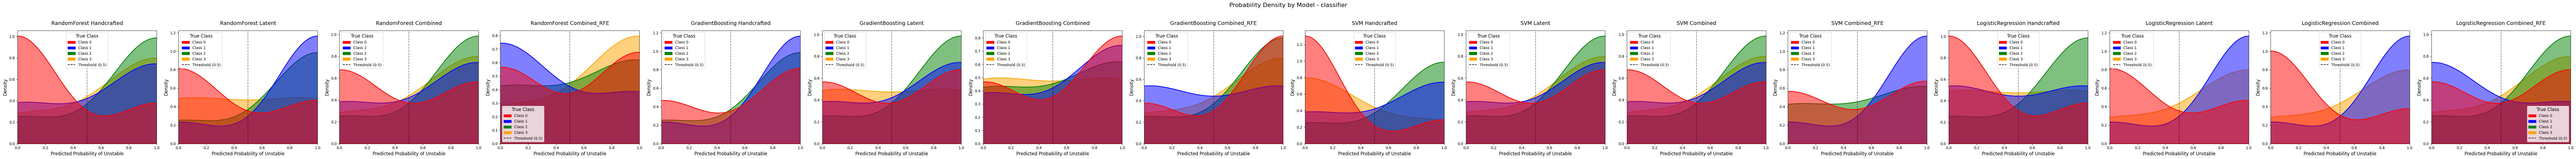

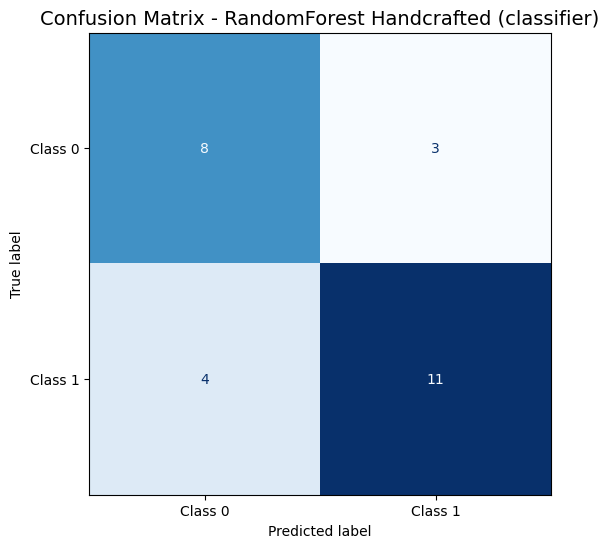

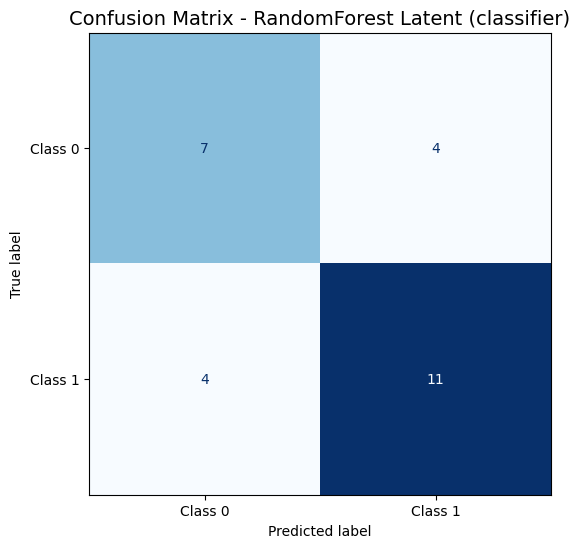

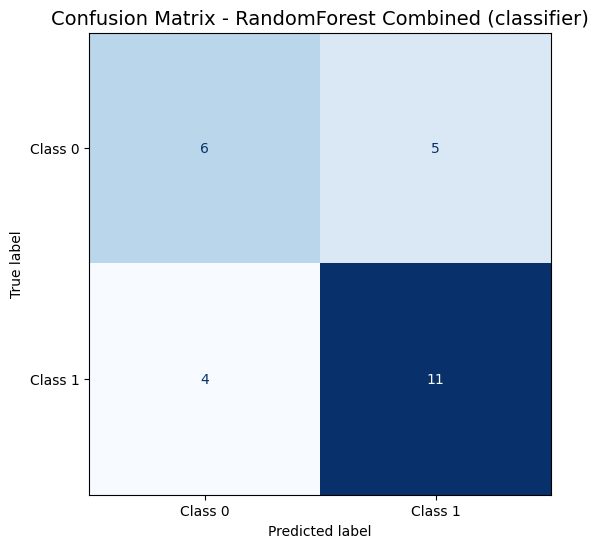

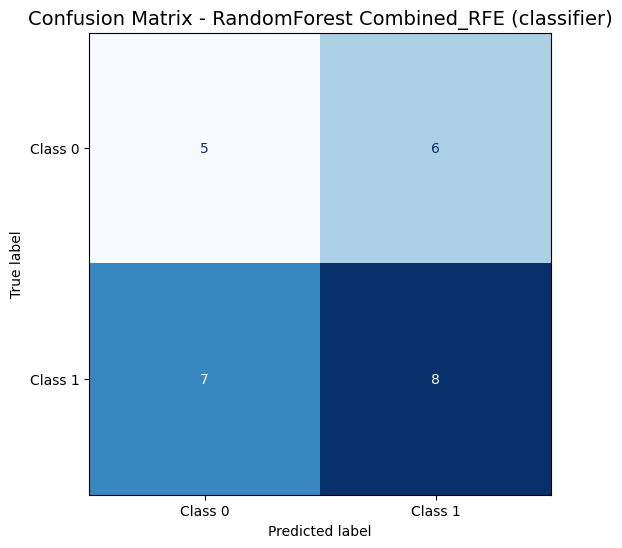

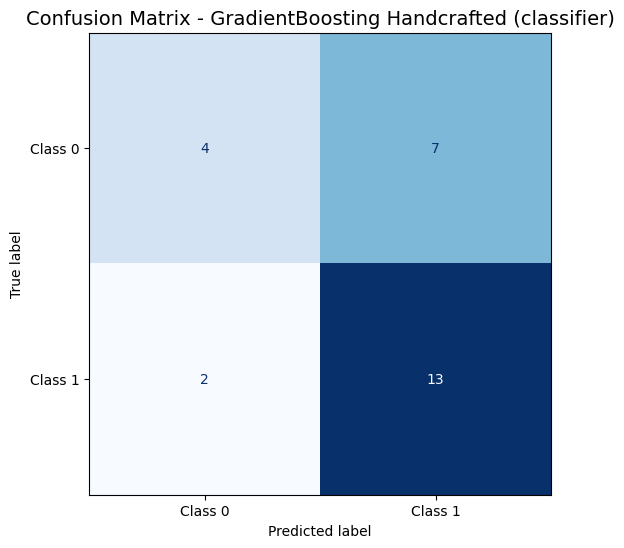

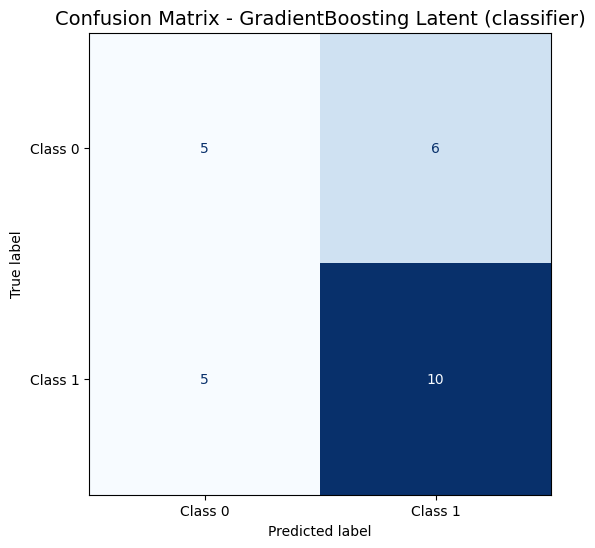

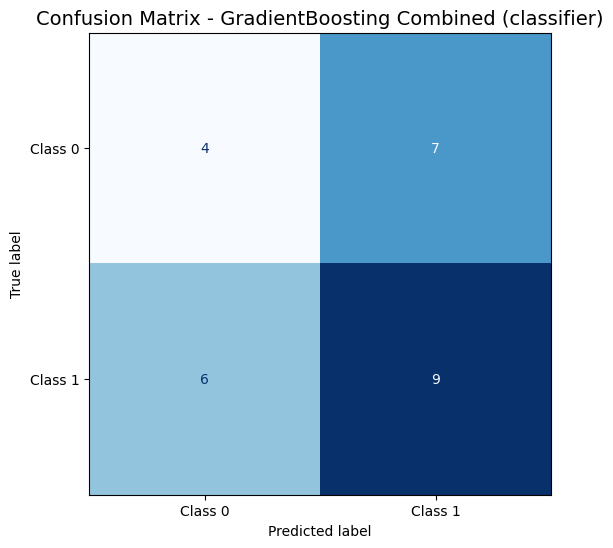

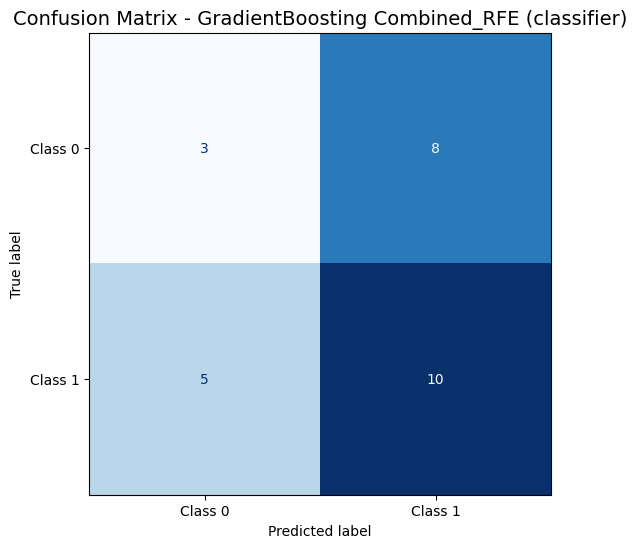

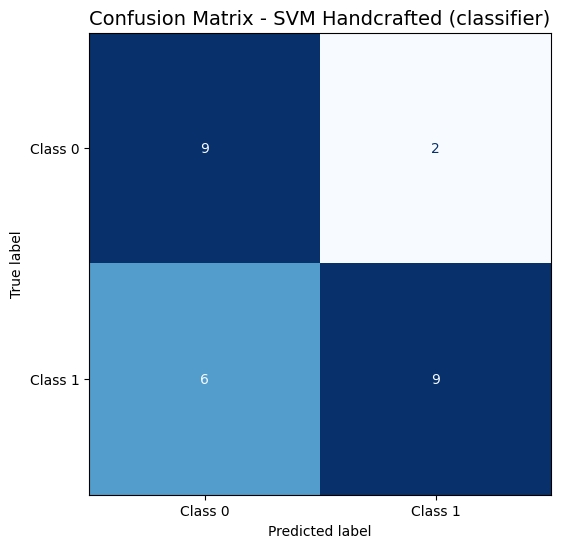

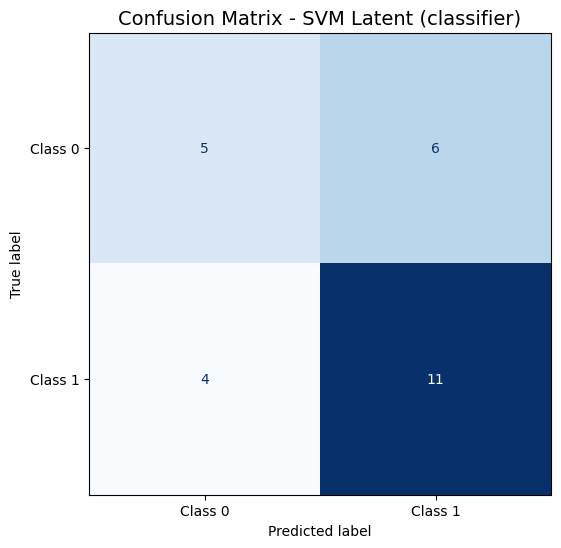

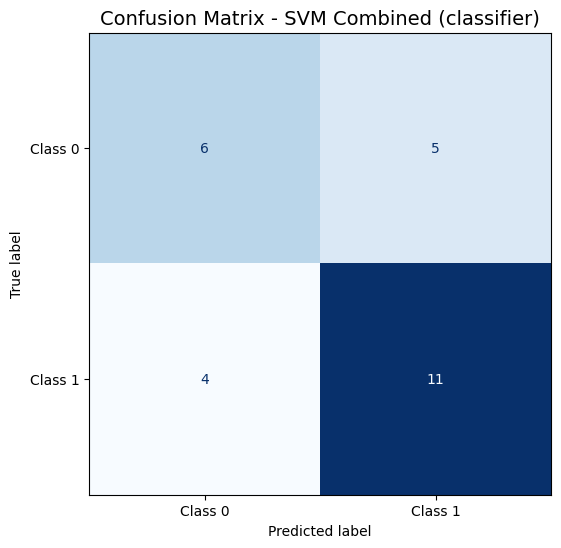

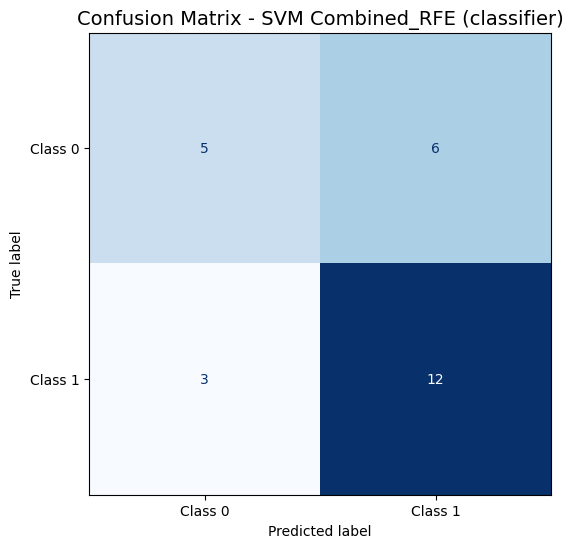

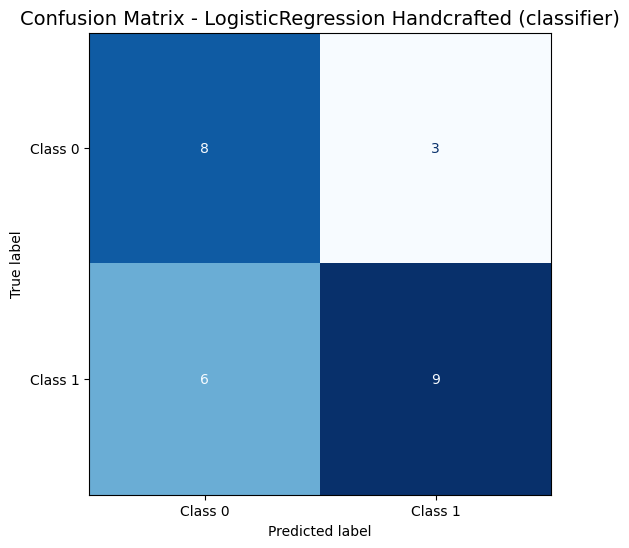

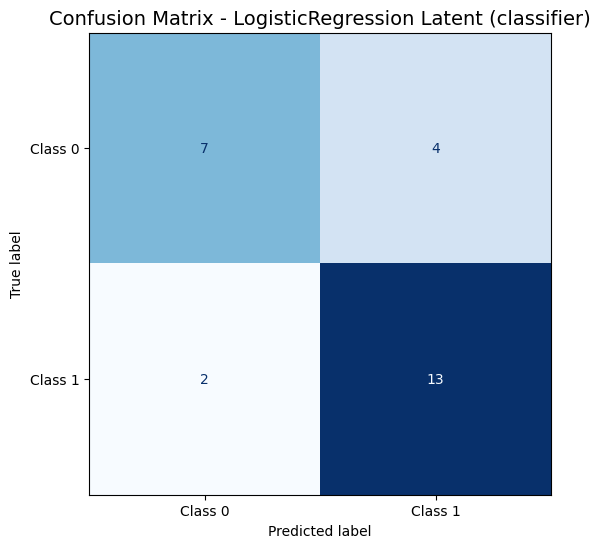

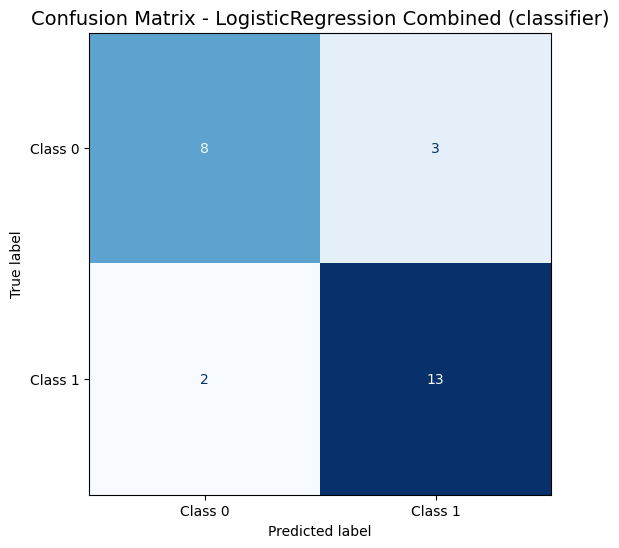

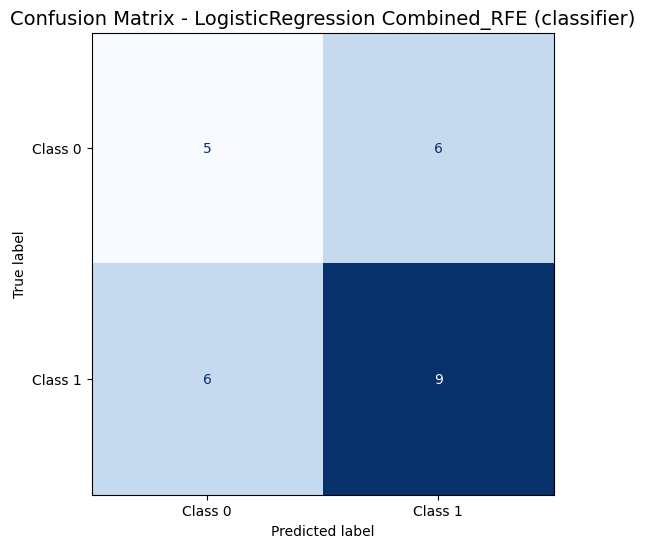


=== Architecture: autoencoder ===


C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\chiar\AppData\Local\Temp\ipykernel_30792\2053991512.py:78: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Us

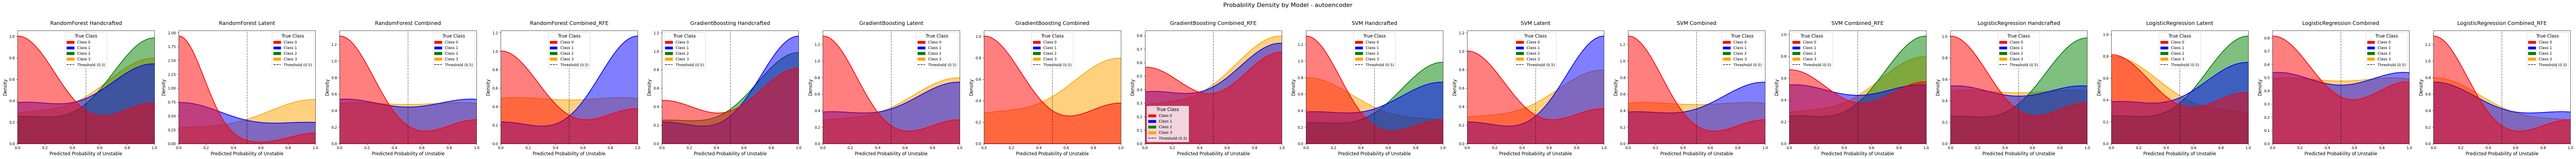

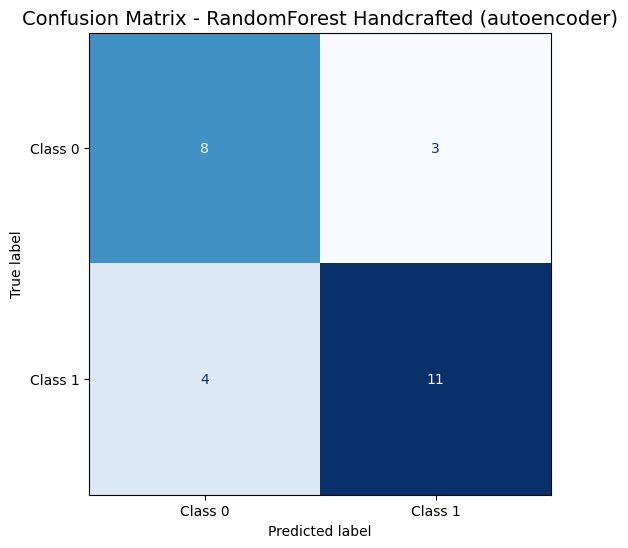

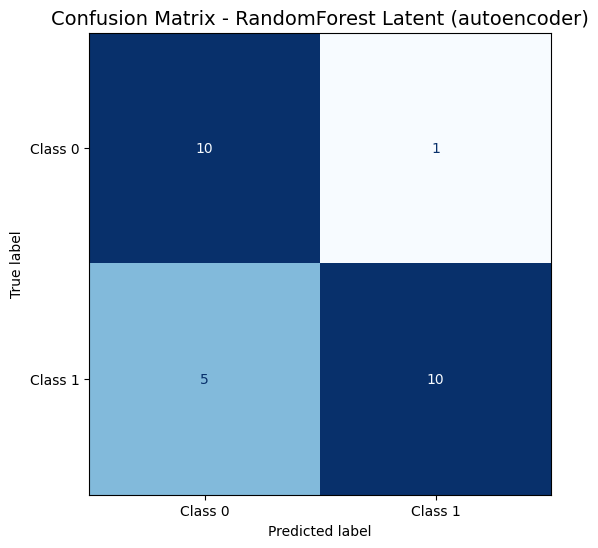

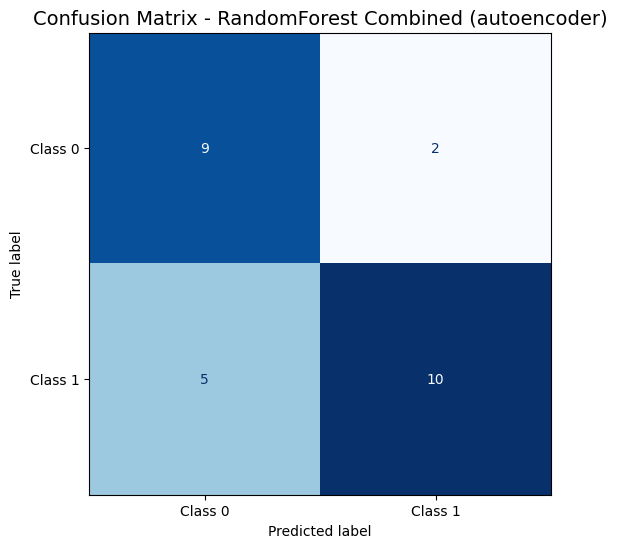

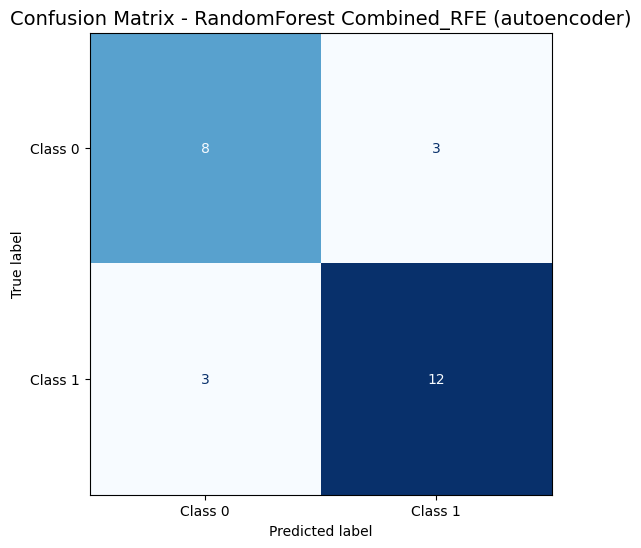

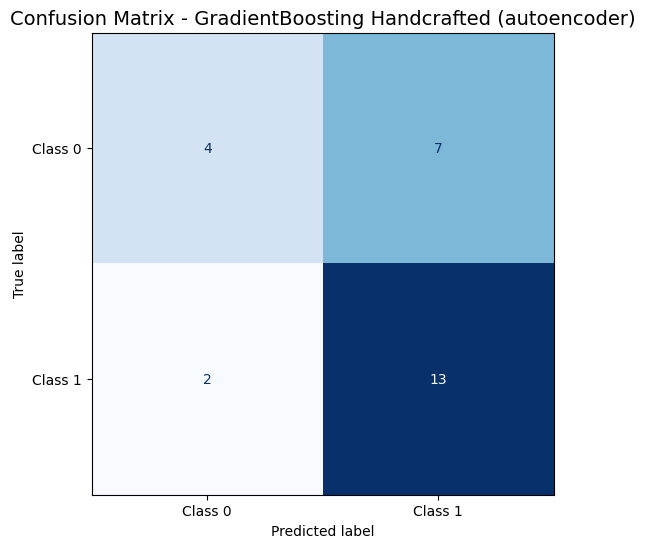

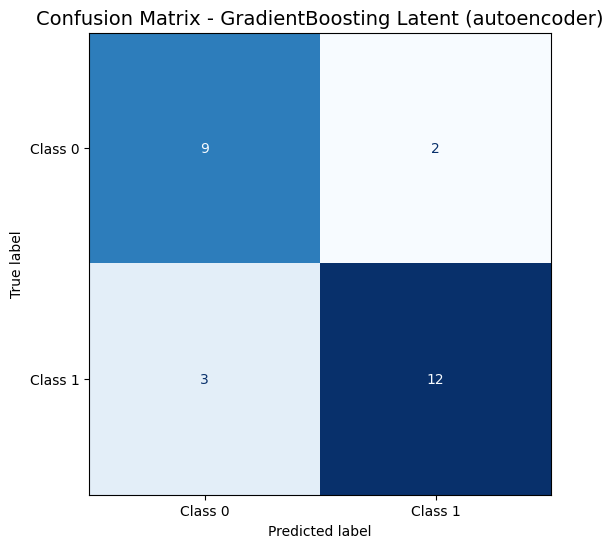

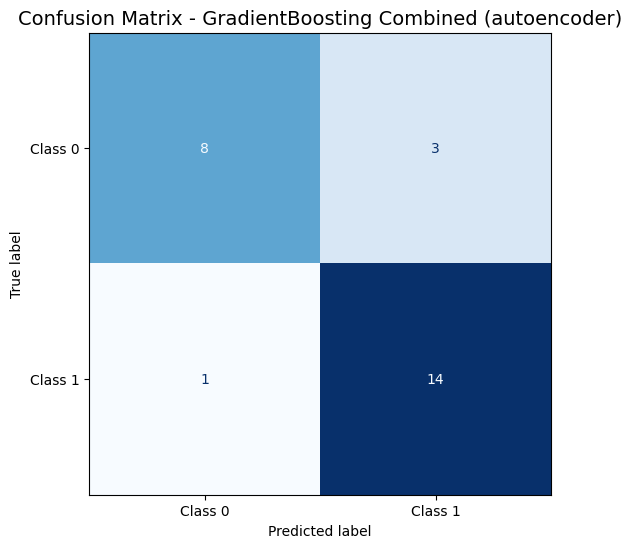

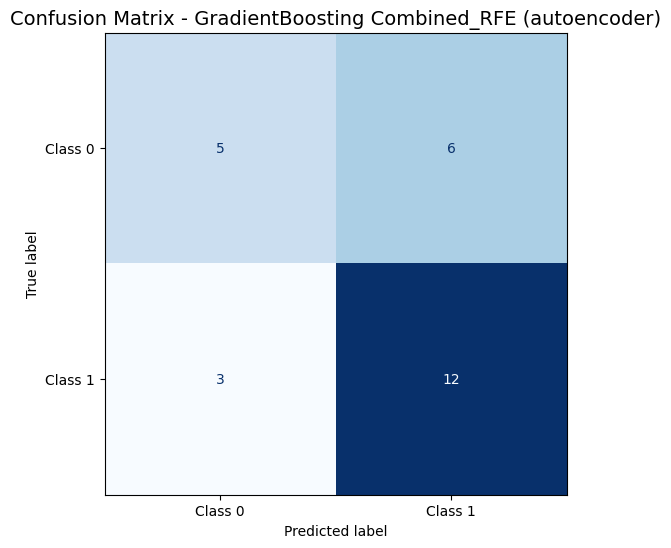

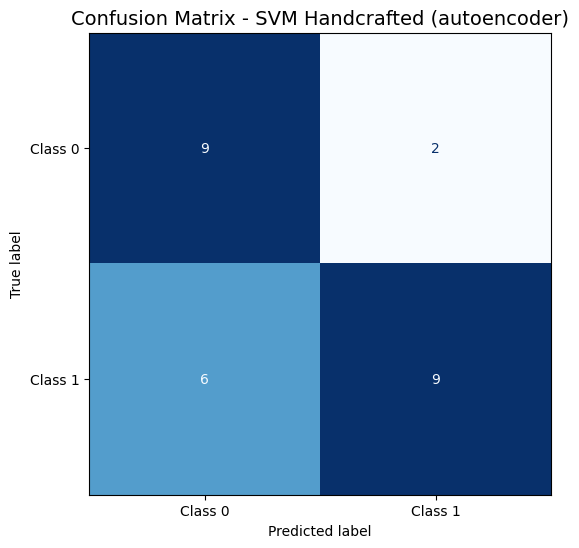

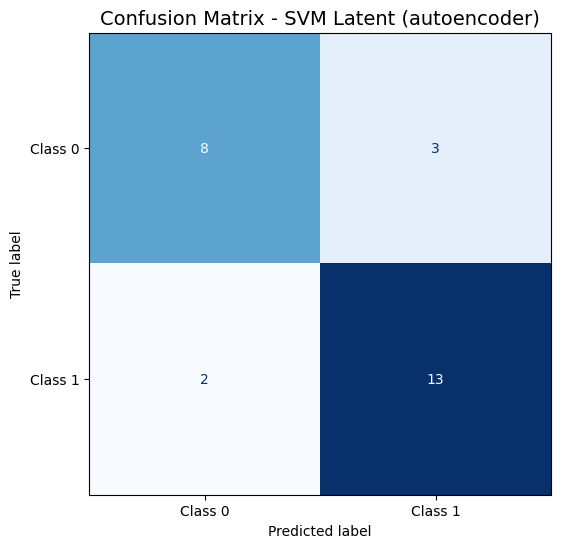

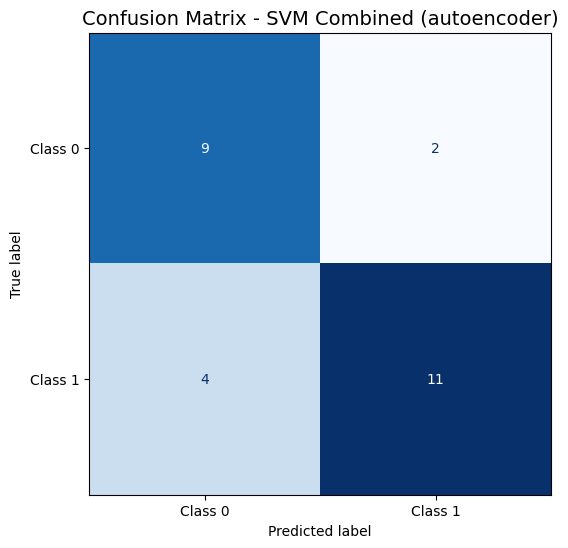

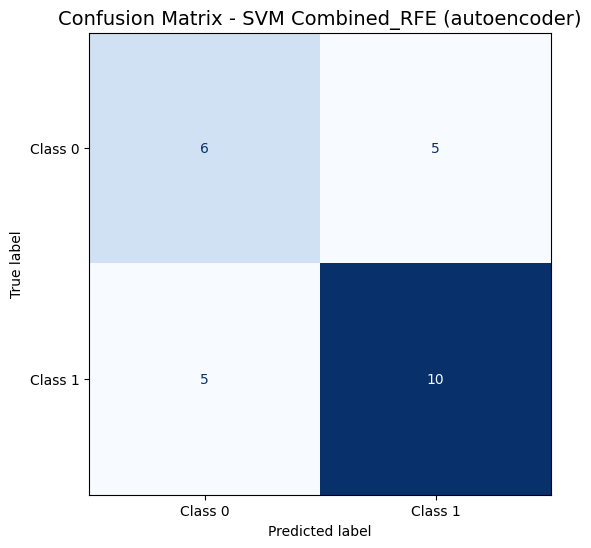

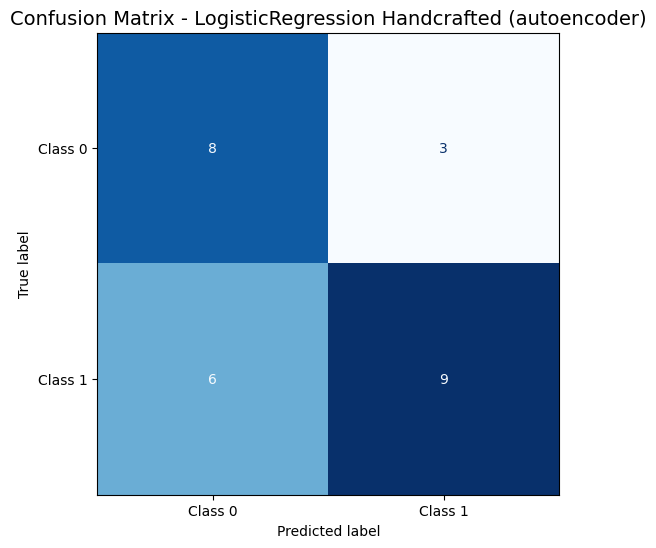

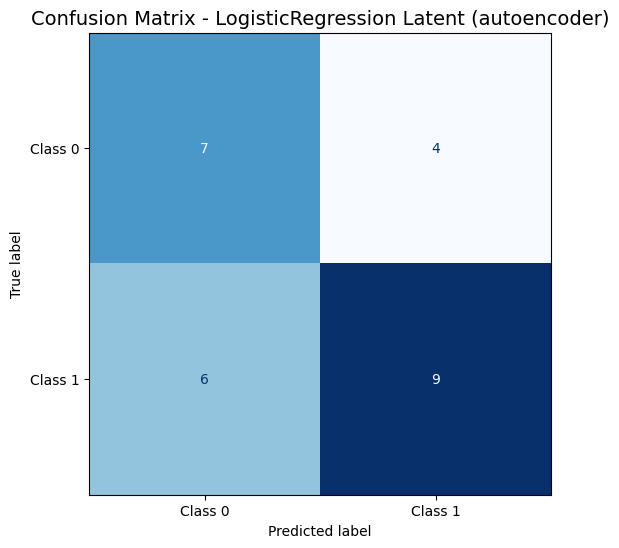

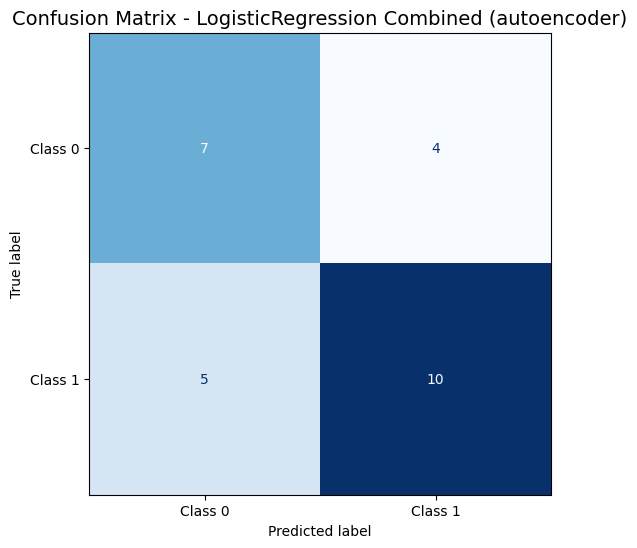

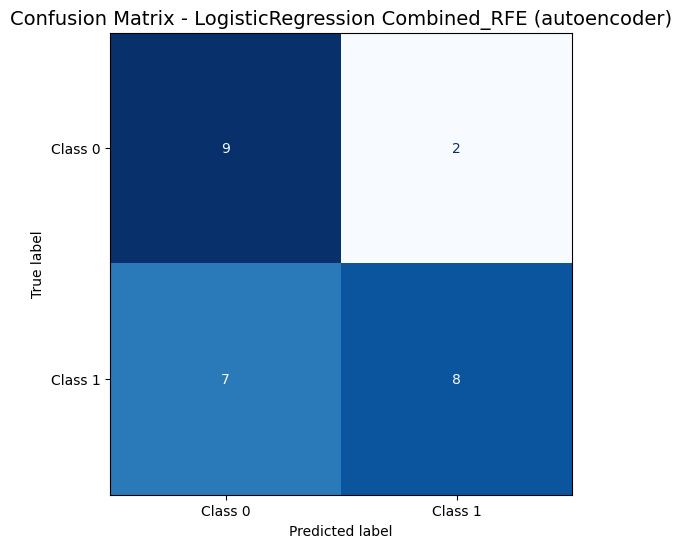

In [15]:
modes = ["classifier", "autoencoder", "classifier_mmd", "autoencoder_mmd"]
RESULTS_PATH = "results/"

models_to_plot = [
    # RandomForest
    ("RandomForest Handcrafted", "y_pred_RandomForest_Handcrafted"),
    ("RandomForest Latent", "y_pred_RandomForest_Latent"),
    ("RandomForest Combined", "y_pred_RandomForest_Combined"),
    ("RandomForest Combined_RFE", "y_pred_RandomForest_Combined_RFE"),
    
    # GradientBoosting
    ("GradientBoosting Handcrafted", "y_pred_GradientBoosting_Handcrafted"),
    ("GradientBoosting Latent", "y_pred_GradientBoosting_Latent"),
    ("GradientBoosting Combined", "y_pred_GradientBoosting_Combined"),
    ("GradientBoosting Combined_RFE", "y_pred_GradientBoosting_Combined_RFE"),
    
    # SVM
    ("SVM Handcrafted", "y_pred_SVM_Handcrafted"),
    ("SVM Latent", "y_pred_SVM_Latent"),
    ("SVM Combined", "y_pred_SVM_Combined"),
    ("SVM Combined_RFE", "y_pred_SVM_Combined_RFE"),
    
    # LogisticRegression
    ("LogisticRegression Handcrafted", "y_pred_LogisticRegression_Handcrafted"),
    ("LogisticRegression Latent", "y_pred_LogisticRegression_Latent"),
    ("LogisticRegression Combined", "y_pred_LogisticRegression_Combined"),
    ("LogisticRegression Combined_RFE", "y_pred_LogisticRegression_Combined_RFE"),
]
# Define explicit colors and labels for classes so the legend is stable
class_colors = {0: "red", 1: "blue", 2: "green", 3: "orange"}
class_labels = {0: "Class 0", 1: "Class 1", 2: "Class 2", 3: "Class 3"}

# Load all available result files first and build a global dataset axis
mode_to_df = {}
all_datasets = set()

for mode in modes:
    file_path = os.path.join(RESULTS_PATH, f"double_ablation_predictions_{mode}.xlsx")
    # print how many true 0 and 1 there are for each dataset in this file (if it exists)
    if not os.path.exists(file_path):
        print(f"[SKIP] File not found for mode '{mode}': {file_path}")
        continue

    df_mode = pd.read_excel(file_path)
    mode_to_df[mode] = df_mode
    if "dataset" in df_mode.columns:
        all_datasets.update(df_mode["dataset"].dropna().astype(str).unique())

if not mode_to_df:
    raise FileNotFoundError("No double_ablation_predictions_*.xlsx files found in results/.")

dataset_order = sorted(all_datasets)
print("Dataset axis used for all architectures:", dataset_order)

for mode in modes:
    if mode not in mode_to_df:
        continue

    ARCH_MODE = mode
    df = mode_to_df[mode].copy()
    print(f"\n=== Architecture: {ARCH_MODE} ===")

    # ----- Density plots (one figure per architecture) -----
    fig, axes = plt.subplots(1, len(models_to_plot), figsize=(6 * len(models_to_plot), 6))
    if len(models_to_plot) == 1:
        axes = [axes]

    for ax, (title, prob_col) in zip(axes, models_to_plot):
        if prob_col not in df.columns:
            ax.set_visible(False)
            print(f"Column {prob_col} not found in {ARCH_MODE}.")
            continue

        # Keep only classes that exist in this architecture file
        unique_classes = sorted(df["y_true_4cls"].dropna().astype(int).unique())
        palette = {c: class_colors.get(c, "gray") for c in unique_classes}
        
        sns.kdeplot(
            data=df,
            x=prob_col,
            hue="y_true_4cls",
            fill=True,
            common_norm=False,
            alpha=0.5,
            linewidth=2,
            ax=ax,
            palette=palette,
        )

        ax.set_title(title, fontsize=14, pad=15)
        ax.set_xlabel("Predicted Probability of Unstable", fontsize=12)
        ax.set_ylabel("Density", fontsize=12)
        ax.set_xlim(0, 1)
        ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Threshold (0.5)")

        # Build a custom legend with specified colors and class labels
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D

        legend_handles = [
            Patch(color=class_colors.get(int(c), "gray"), label=class_labels.get(int(c), str(c)))
            for c in unique_classes
        ]
        threshold_handle = Line2D([0], [0], color="black", linestyle="--")
        legend_handles.append(threshold_handle)
        legend_labels = [class_labels.get(int(c), str(c)) for c in unique_classes] + ["Threshold (0.5)"]
        ax.legend(legend_handles, legend_labels, title="True Class", fontsize=10, title_fontsize=12)

    fig.suptitle(f"Probability Density by Model - {ARCH_MODE}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # plot classification matrix for each model in this architecture 
    for title, prob_col in models_to_plot:
        if prob_col not in df.columns:
            print(f"Column {prob_col} not found in {ARCH_MODE}, skipping classification matrix.")
            continue

        # Create binary predictions based on 0.5 threshold
        df["y_pred_binary"] = (df[prob_col] >= 0.5).astype(int)

        # Compute confusion matrix
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

        y_true = df["y_true"].dropna().astype(int)
        y_pred = df["y_pred_binary"].loc[y_true.index]

        cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[class_labels.get(c, str(c)) for c in sorted(y_true.unique())])
        
        fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
        disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
        ax_cm.set_title(f"Confusion Matrix - {title} ({ARCH_MODE})", fontsize=14)
        plt.show()
   

In [3]:
df = pd.read_csv("data/metadata.csv")


In [4]:
# print label distribution for each dataset mapping 0:0, 1,2,3,4: 1
df["label"] = df["label"].map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})
label_distribution = df.groupby("dataset")["label"].value_counts(normalize=True).unstack(fill_value=0)
print("\nLabel distribution (0 vs 1) for each dataset:")
print(label_distribution)



Label distribution (0 vs 1) for each dataset:
label             0        1
dataset                     
kiel        0.28169  0.71831
omnia_park  0.23174  0.76826
wearpd      0.28145  0.71855
